## EXPLORATORY DATA ANALYSIS (EDA)

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv(r"D:\Telco Customer Churn\data\Original_dataset.csv")

In [3]:
df["TotalCharges"] = pd.to_numeric(
    df["TotalCharges"],
    errors="coerce"
)

In [4]:
df["Churn_Encoded"] = df["Churn"].map({
    "No": 0,
    "Yes": 1
})

In [5]:
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn,Churn_Encoded
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No,0
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,No,No,No,One year,No,Mailed check,56.95,1889.50,No,0
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes,1
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No,0
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes,1


In [6]:
numeric_features = [
    "tenure",
    "MonthlyCharges",
    "TotalCharges"
]

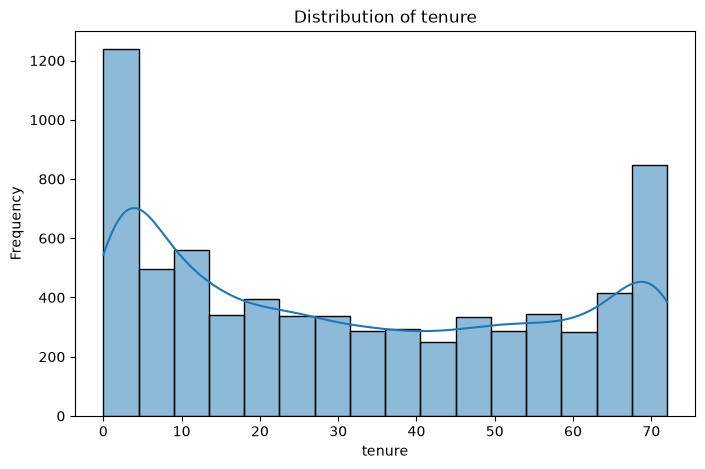

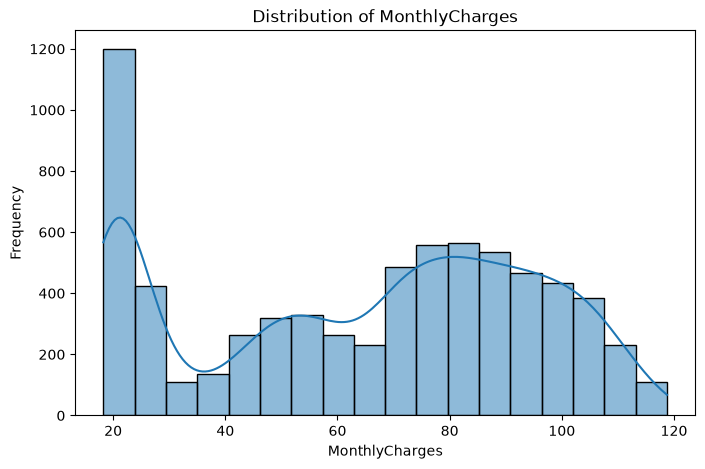

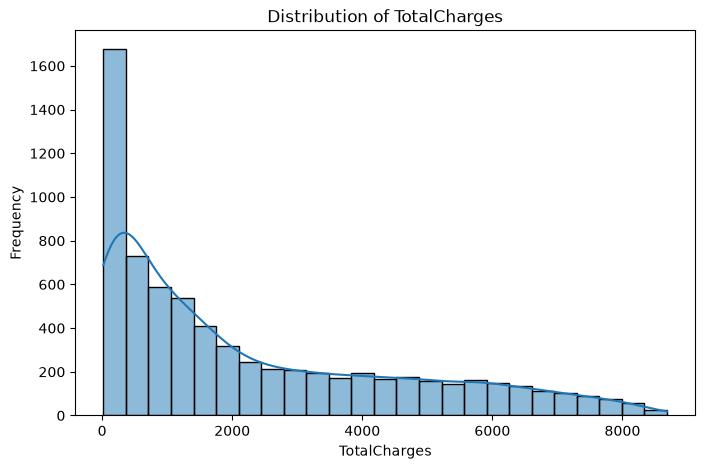

In [7]:
for column in numeric_features:

    plt.figure(figsize=(8, 5))

    sns.histplot(
        data=df,
        x=column,
        kde=True
    )

    plt.title(f"Distribution of {column}")
    plt.xlabel(column)
    plt.ylabel("Frequency")

    plt.show()

In [8]:
for column in numeric_features:

    print(f"\n{column}")

    print("Mean:", df[column].mean())
    print("Median:", df[column].median())


tenure
Mean: 32.37114865824223
Median: 29.0

MonthlyCharges
Mean: 64.76169246059918
Median: 70.35

TotalCharges
Mean: 2283.3004408418656
Median: 1397.475


In [9]:
stats = pd.DataFrame({
    "Mean": df[numeric_features].mean(),
    "Median": df[numeric_features].median(),
    "Std": df[numeric_features].std(),
    "Min": df[numeric_features].min(),
    "Max": df[numeric_features].max()
})

print(stats)

                       Mean    Median          Std    Min      Max
tenure            32.371149    29.000    24.559481   0.00    72.00
MonthlyCharges    64.761692    70.350    30.090047  18.25   118.75
TotalCharges    2283.300441  1397.475  2266.771362  18.80  8684.80


In [10]:
for column in numeric_features:
    
    skew_value = df[column].skew()

    print(f"{column}: {skew_value:.3f}")

tenure: 0.240
MonthlyCharges: -0.221
TotalCharges: 0.962


In [11]:
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn,Churn_Encoded
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No,0
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,No,No,No,One year,No,Mailed check,56.95,1889.50,No,0
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes,1
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No,0
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes,1


In [12]:
categorical_features = [
    "gender",
    "Contract",
    "InternetService",
    "PaymentMethod",
    "Partner",
    "Dependents",
    "PhoneService",
    "MultipleLines",
    "OnlineSecurity",
    "OnlineBackup",
    "DeviceProtection",
    "TechSupport",
    "StreamingTV",
    "StreamingMovies",
    "PaperlessBilling",
    "SeniorCitizen"
]

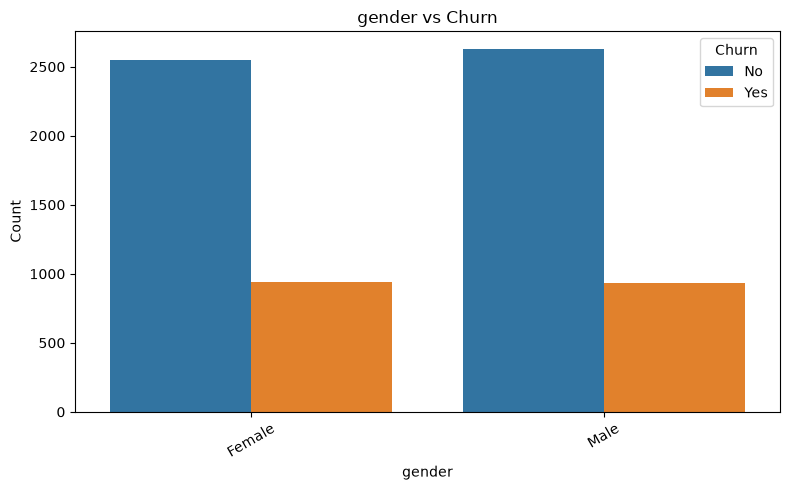

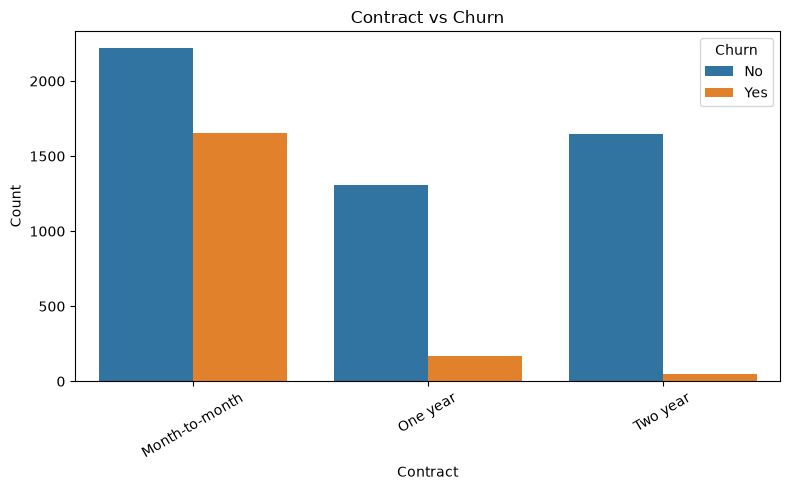

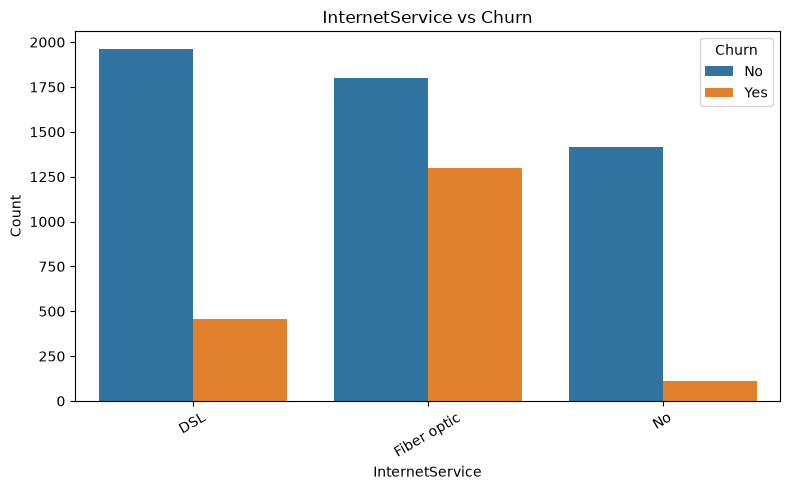

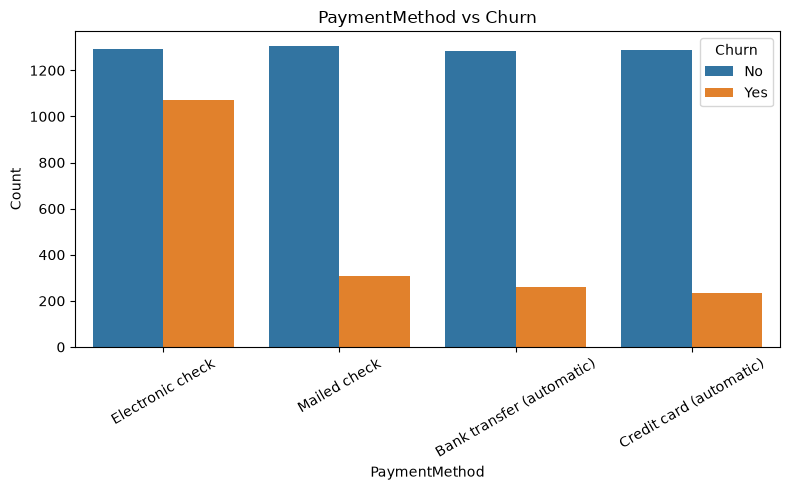

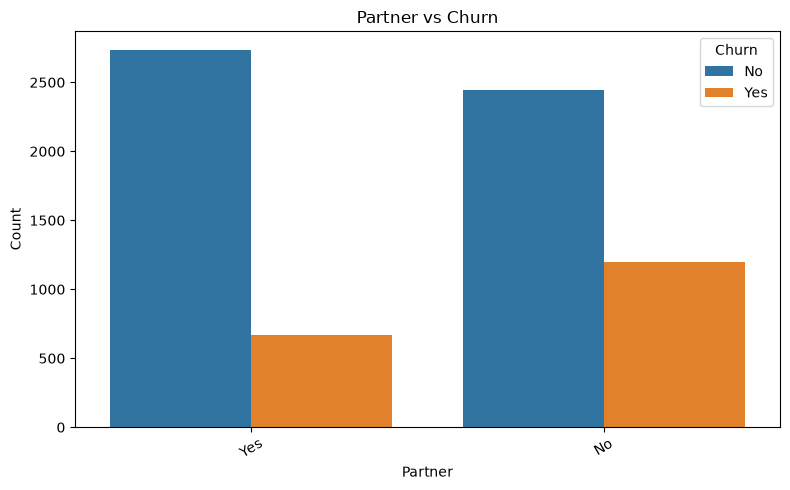

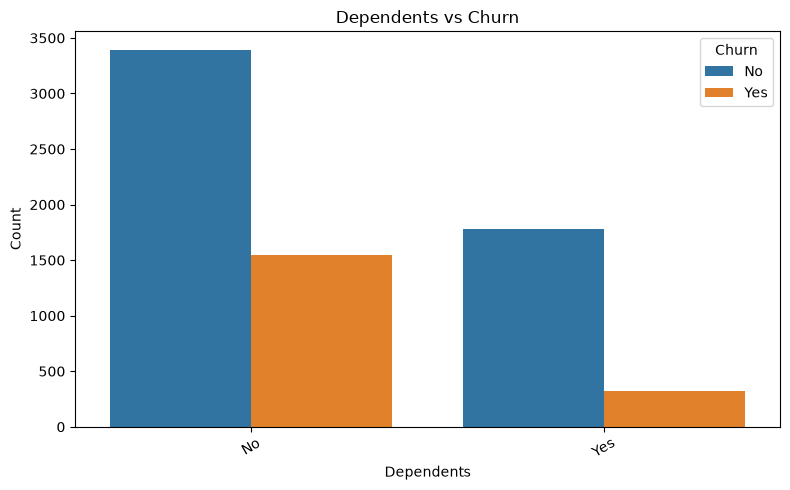

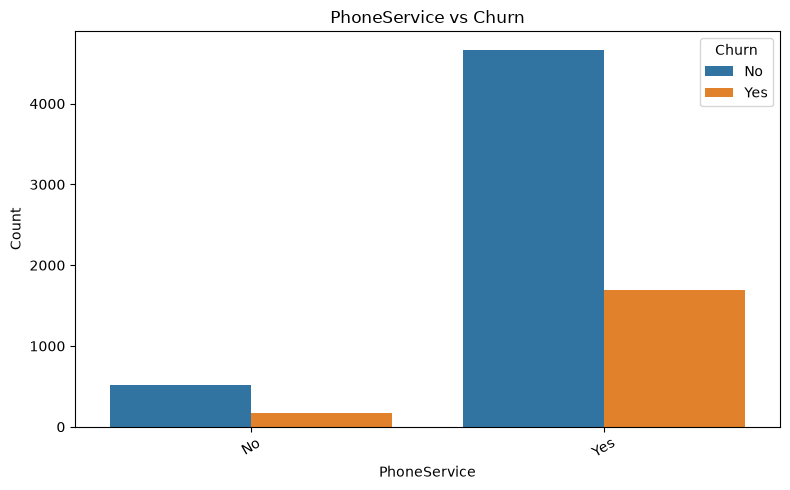

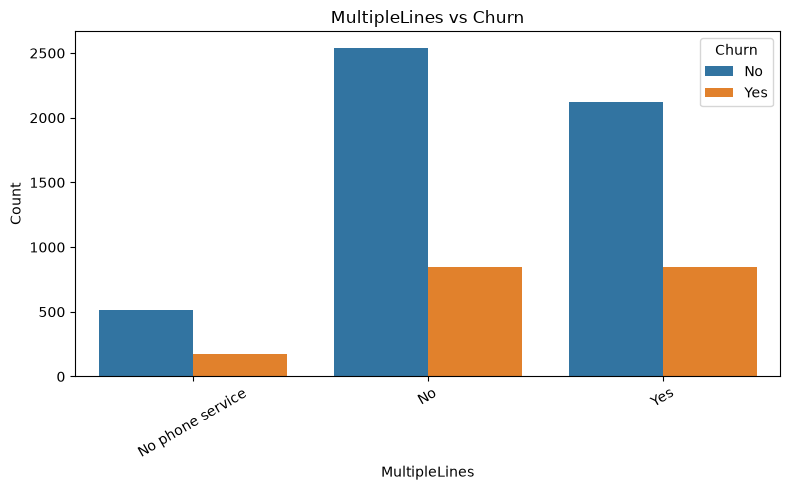

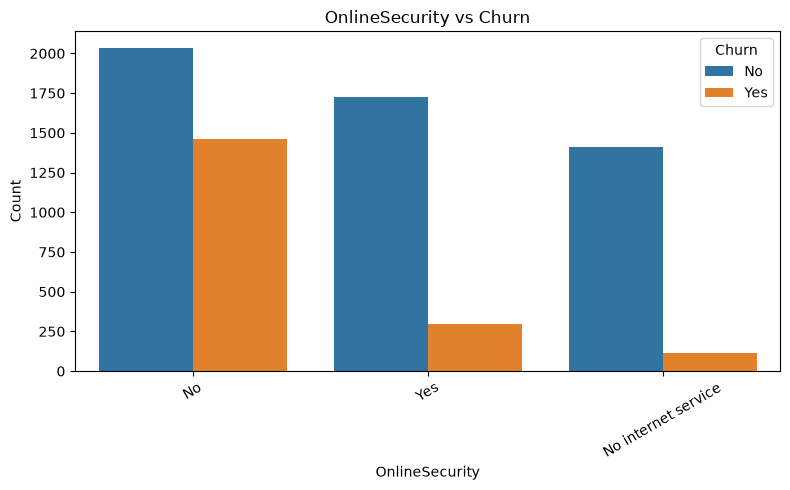

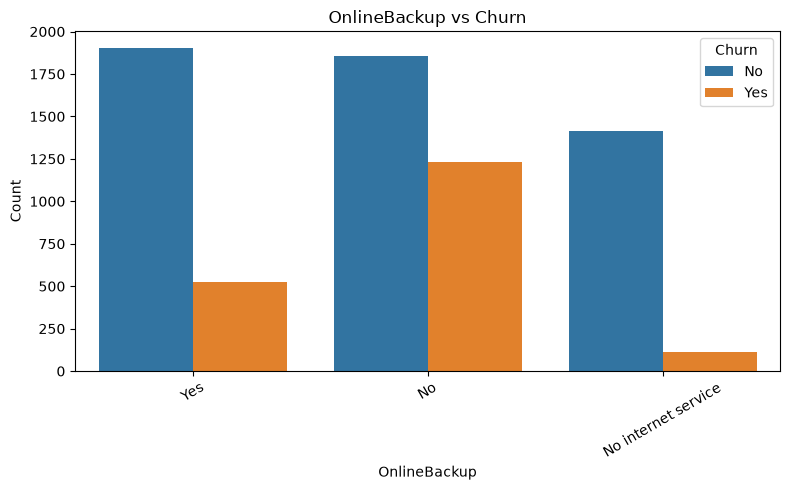

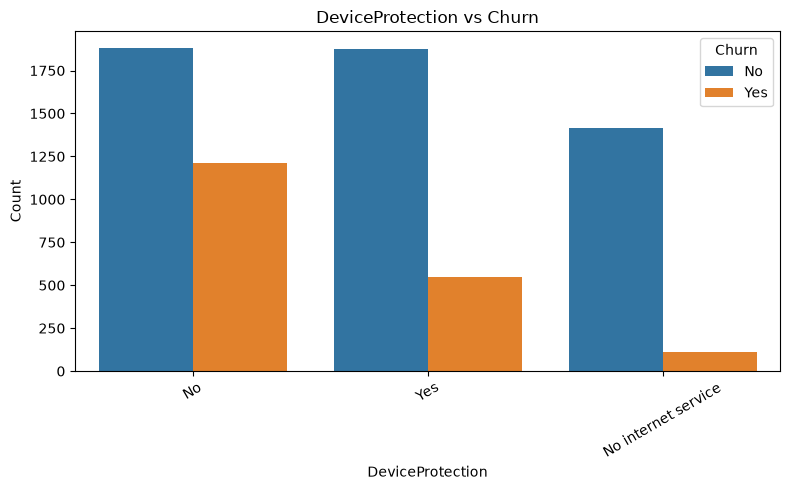

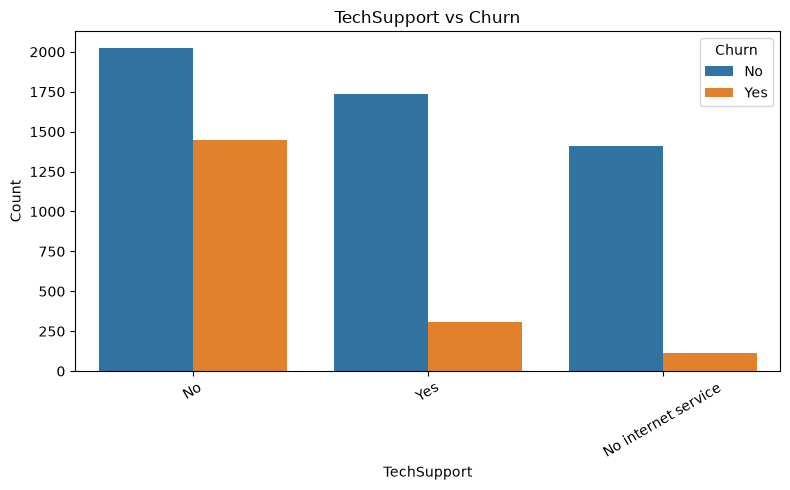

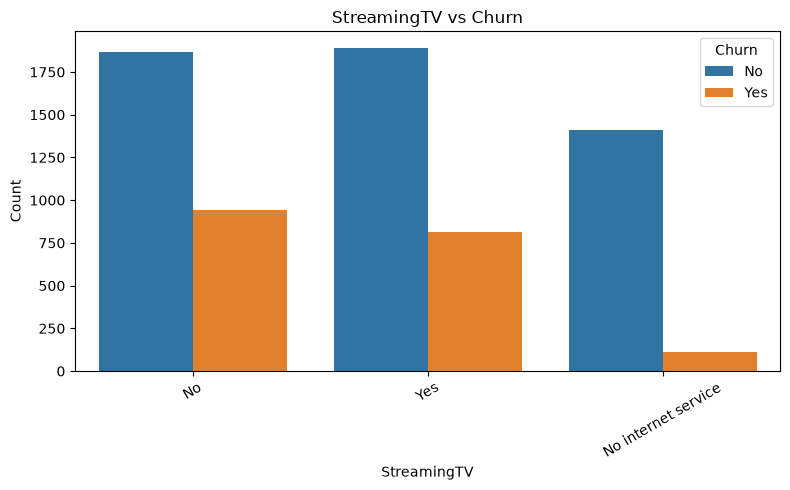

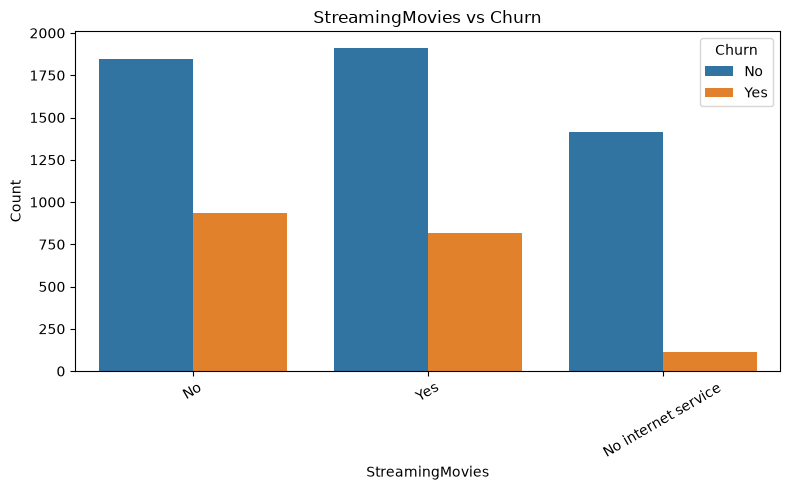

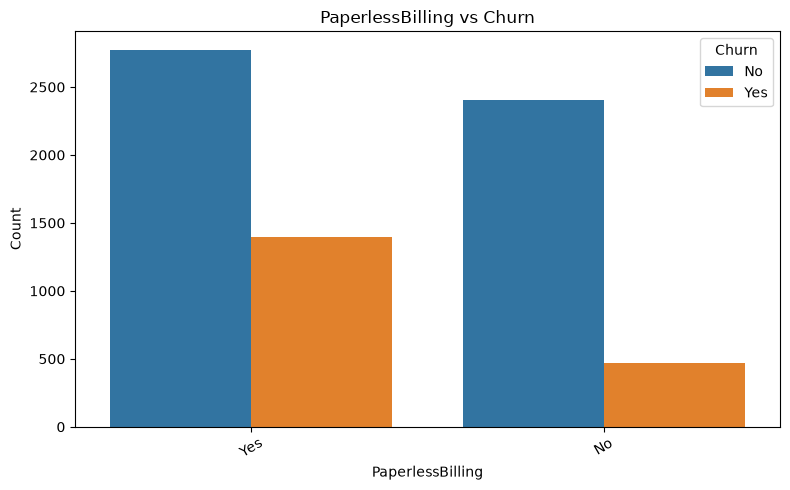

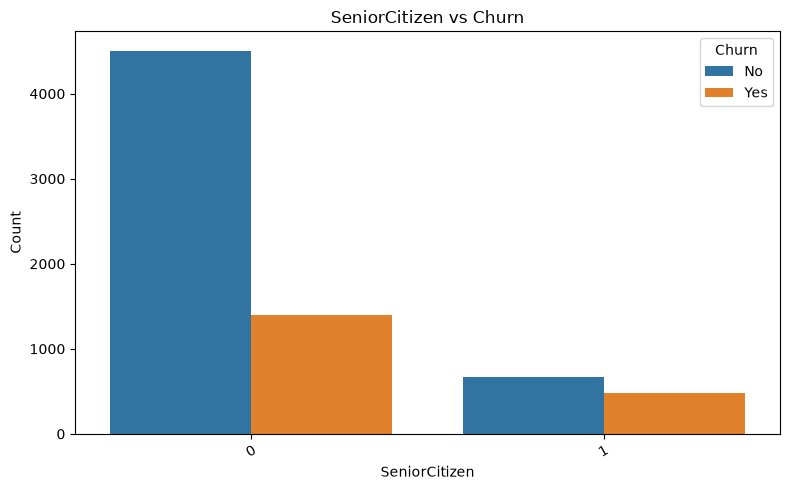

In [13]:
for column in categorical_features:

    plt.figure(figsize=(8, 5))

    sns.countplot(
        data=df,
        x=column,
        hue="Churn"
    )

    plt.title(f"{column} vs Churn")
    plt.xlabel(column)
    plt.ylabel("Count")

    plt.xticks(rotation=30)

    plt.tight_layout()
    plt.show()

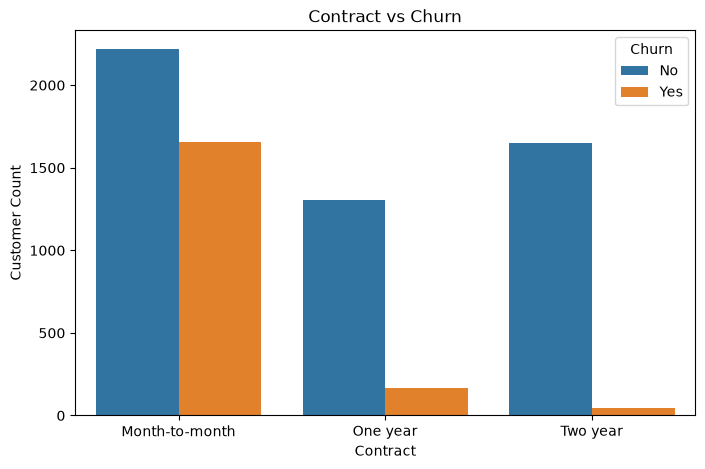

In [14]:
plt.figure(figsize=(8, 5))

sns.countplot(
    data=df,
    x="Contract",
    hue="Churn"
)

plt.title("Contract vs Churn")
plt.xlabel("Contract")
plt.ylabel("Customer Count")

plt.show()

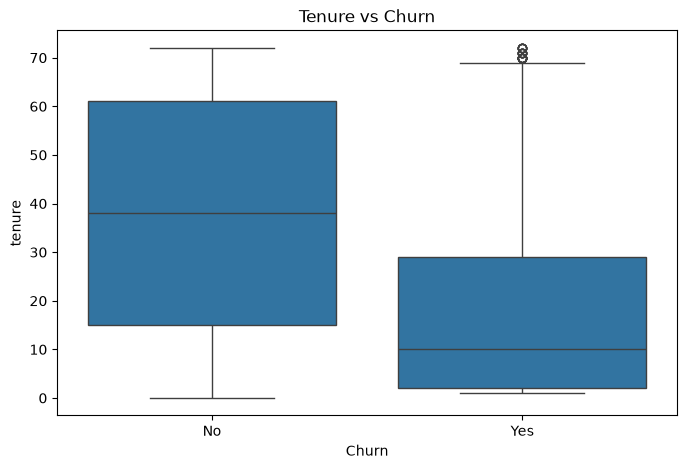

In [15]:
plt.figure(figsize=(8, 5))

sns.boxplot(
    data=df,
    x="Churn",
    y="tenure"
)

plt.title("Tenure vs Churn")

plt.show()

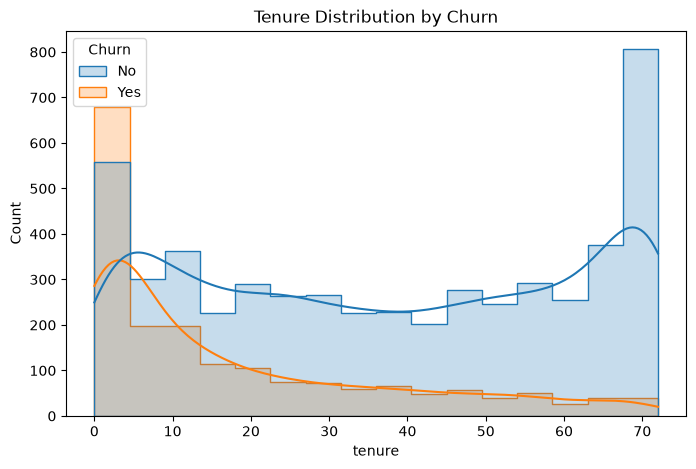

In [16]:
plt.figure(figsize=(8, 5))

sns.histplot(
    data=df,
    x="tenure",
    hue="Churn",
    kde=True,
    element="step"
)

plt.title("Tenure Distribution by Churn")

plt.show()

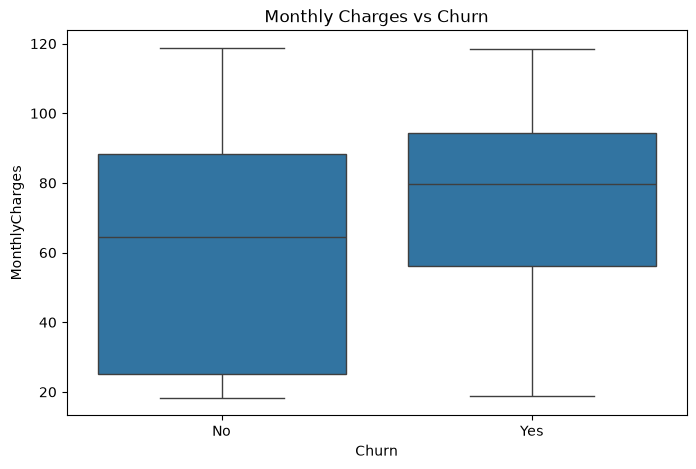

In [17]:
plt.figure(figsize=(8, 5))

sns.boxplot(
    data=df,
    x="Churn",
    y="MonthlyCharges"
)

plt.title("Monthly Charges vs Churn")

plt.show()

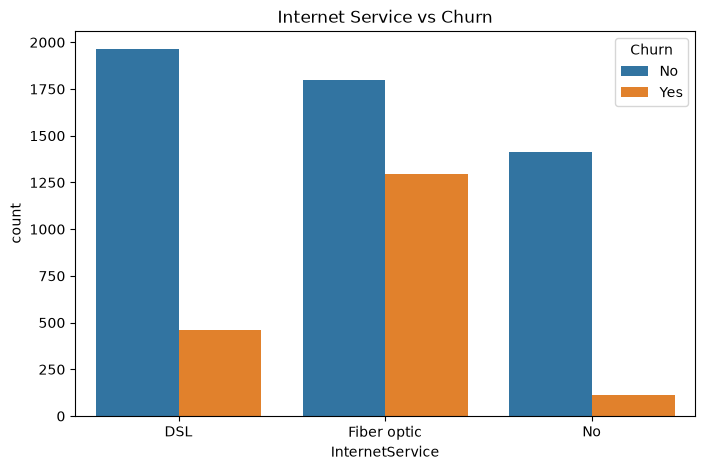

In [18]:
plt.figure(figsize=(8, 5))

sns.countplot(
    data=df,
    x="InternetService",
    hue="Churn"
)

plt.title("Internet Service vs Churn")

plt.show()

In [19]:
internet_churn = pd.crosstab(
    df["InternetService"],
    df["Churn"],
    normalize="index"
) * 100

print(internet_churn)

Churn                   No        Yes
InternetService                      
DSL              81.040892  18.959108
Fiber optic      58.107235  41.892765
No               92.595020   7.404980


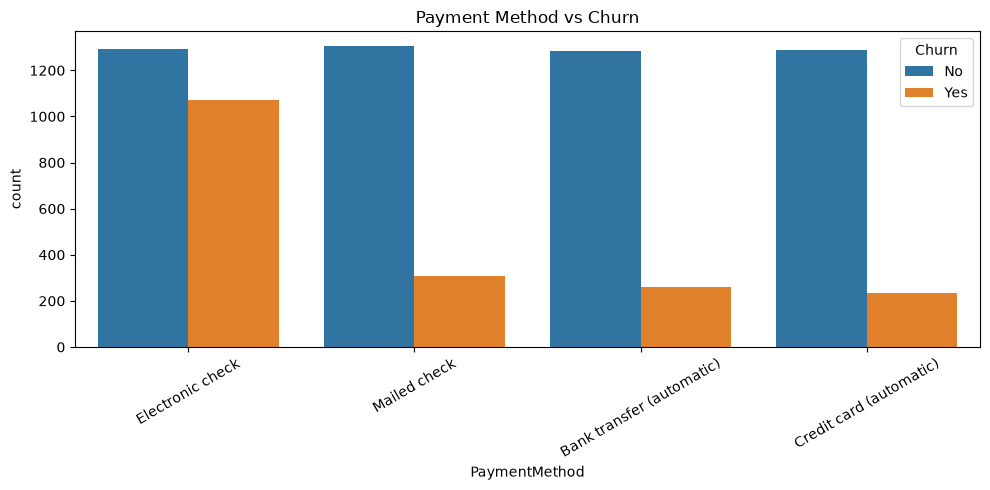

In [20]:
plt.figure(figsize=(10, 5))

sns.countplot(
    data=df,
    x="PaymentMethod",
    hue="Churn"
)

plt.title("Payment Method vs Churn")
plt.xticks(rotation=30)

plt.tight_layout()
plt.show()

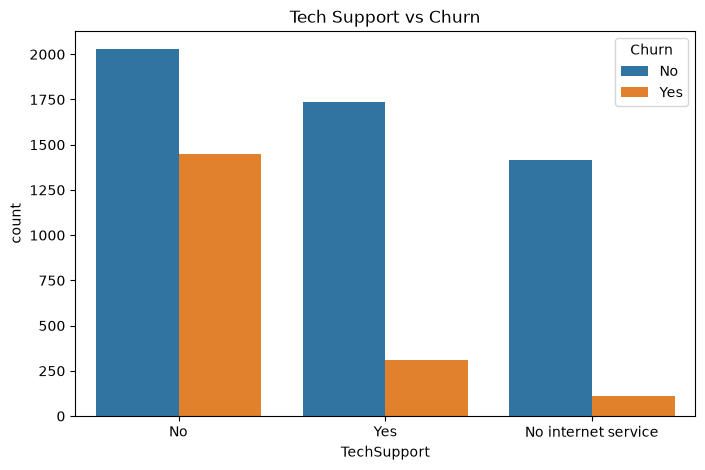

In [21]:
plt.figure(figsize=(8, 5))

sns.countplot(
    data=df,
    x="TechSupport",
    hue="Churn"
)

plt.title("Tech Support vs Churn")

plt.show()

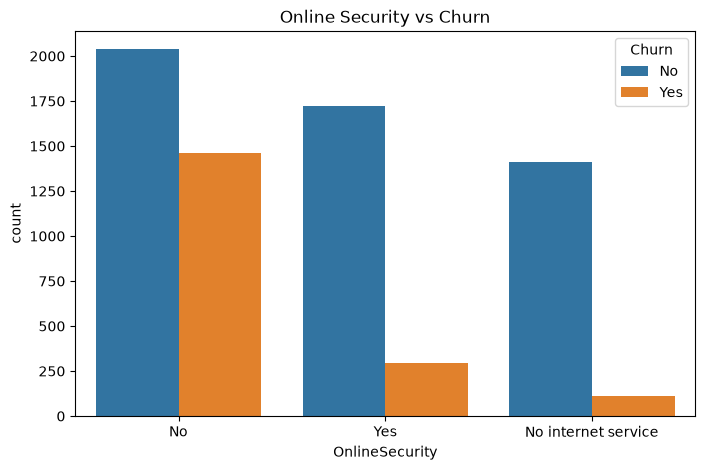

In [22]:
plt.figure(figsize=(8, 5))

sns.countplot(
    data=df,
    x="OnlineSecurity",
    hue="Churn"
)

plt.title("Online Security vs Churn")

plt.show()

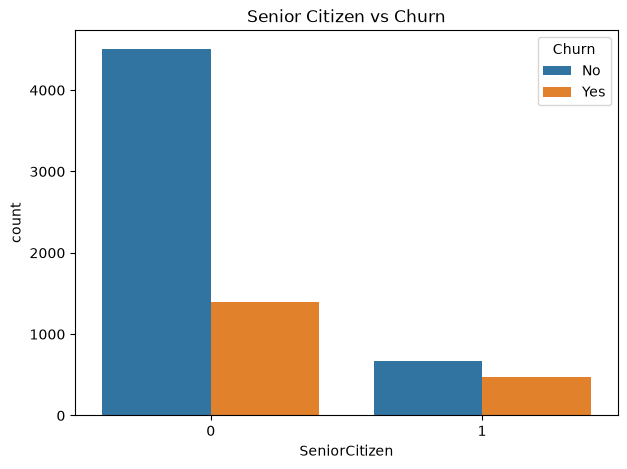

In [23]:
plt.figure(figsize=(7, 5))

sns.countplot(
    data=df,
    x="SeniorCitizen",
    hue="Churn"
)

plt.title("Senior Citizen vs Churn")

plt.show()

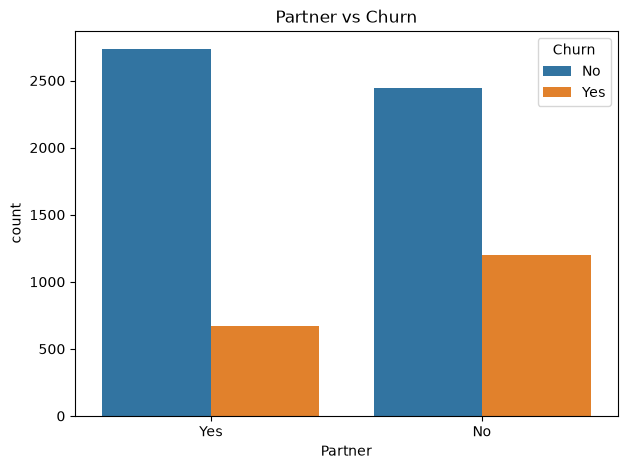

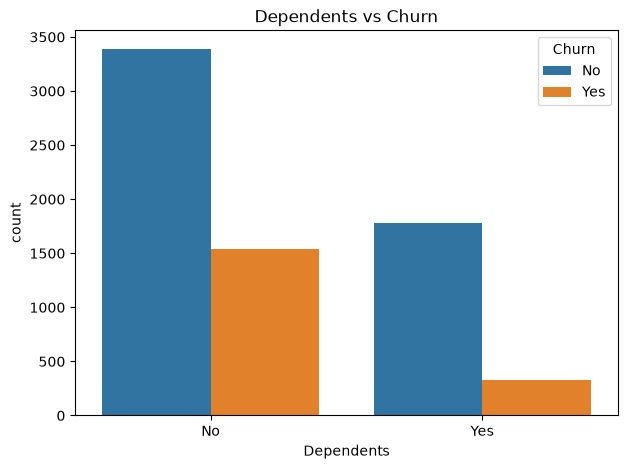

In [24]:
figures = [
    "Partner",
    "Dependents"
]

for column in figures:

    plt.figure(figsize=(7, 5))

    sns.countplot(
        data=df,
        x=column,
        hue="Churn"
    )

    plt.title(f"{column} vs Churn")

    plt.show()

In [25]:

correlation = df[numeric_features].corr()

print(correlation)

                 tenure  MonthlyCharges  TotalCharges
tenure          1.00000        0.247900      0.825880
MonthlyCharges  0.24790        1.000000      0.651065
TotalCharges    0.82588        0.651065      1.000000


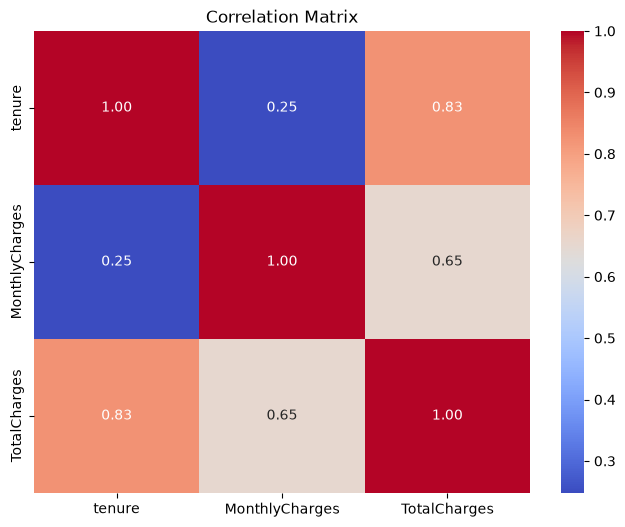

In [26]:
plt.figure(figsize=(8, 6))

sns.heatmap(
    correlation,
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Correlation Matrix")

plt.show()

In [27]:
churn_correlation = df[
    numeric_features + ["Churn_Encoded"]
].corr()["Churn_Encoded"].sort_values(
    ascending=False
)

print(churn_correlation)

Churn_Encoded     1.000000
MonthlyCharges    0.193356
TotalCharges     -0.199484
tenure           -0.352229
Name: Churn_Encoded, dtype: float64


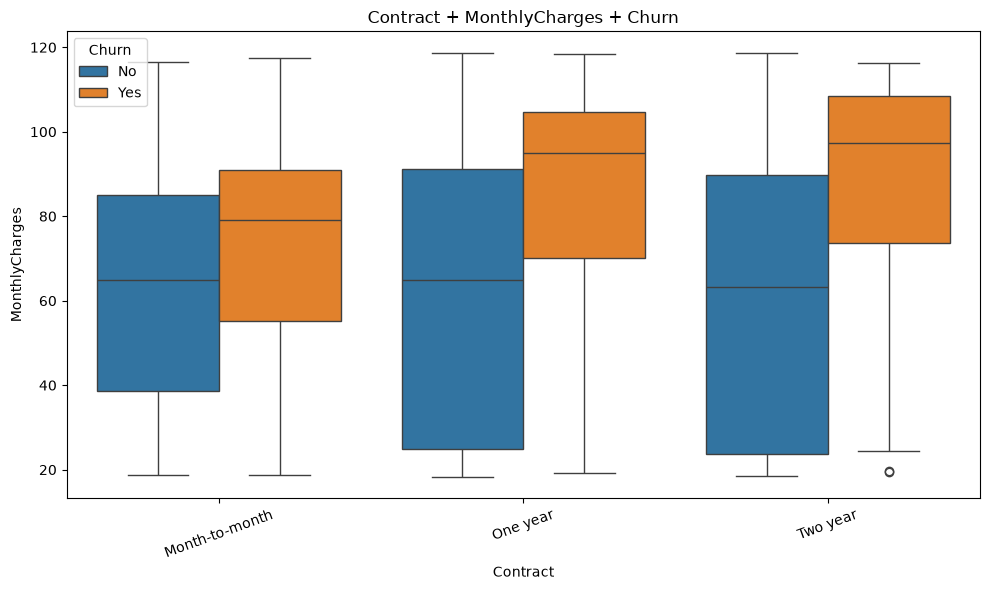

In [28]:
plt.figure(figsize=(10, 6))

sns.boxplot(
    data=df,
    x="Contract",
    y="MonthlyCharges",
    hue="Churn"
)

plt.title(
    "Contract + MonthlyCharges + Churn"
)

plt.xticks(rotation=20)

plt.tight_layout()
plt.show()

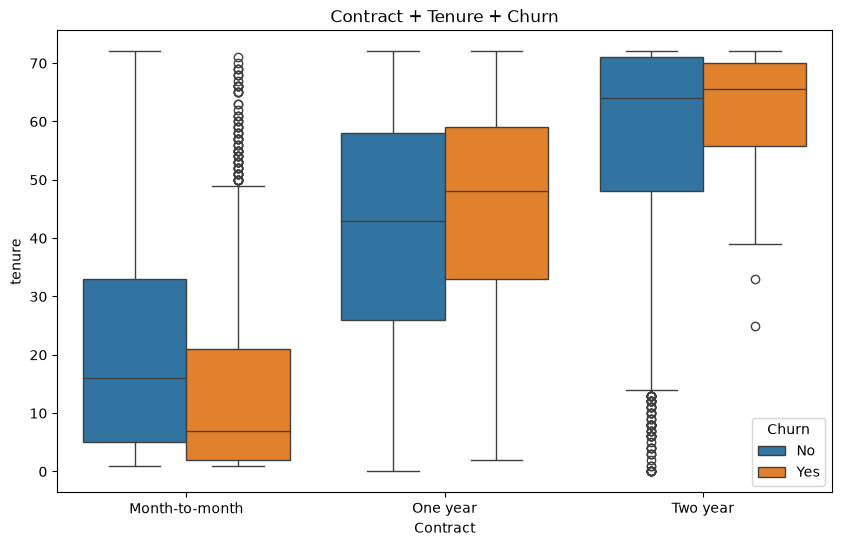

In [29]:
plt.figure(figsize=(10, 6))

sns.boxplot(
    data=df,
    x="Contract",
    y="tenure",
    hue="Churn"
)

plt.title(
    "Contract + Tenure + Churn"
)

plt.show()

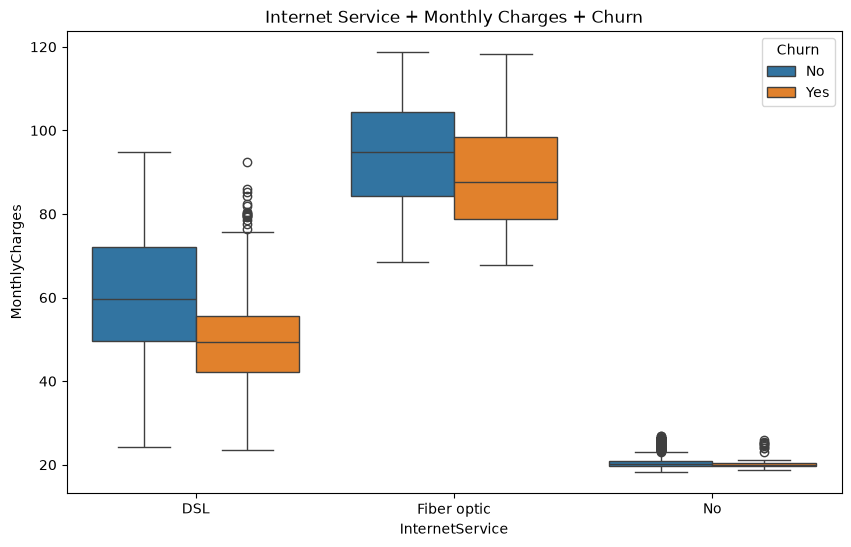

In [30]:
plt.figure(figsize=(10, 6))

sns.boxplot(
    data=df,
    x="InternetService",
    y="MonthlyCharges",
    hue="Churn"
)

plt.title(
    "Internet Service + Monthly Charges + Churn"
)

plt.show()

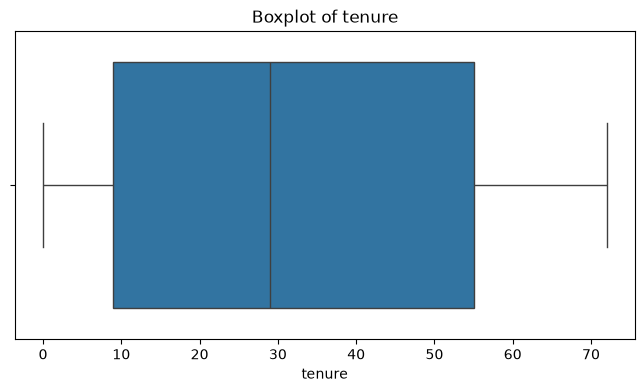

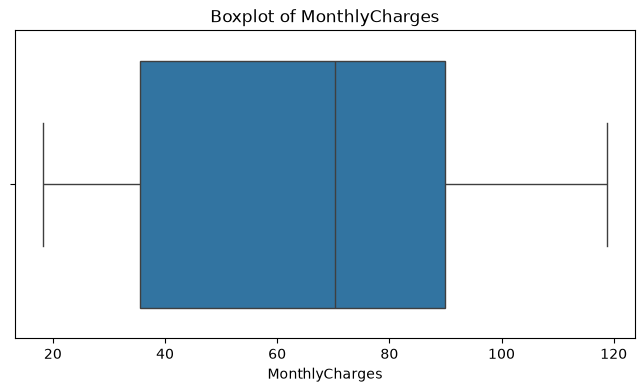

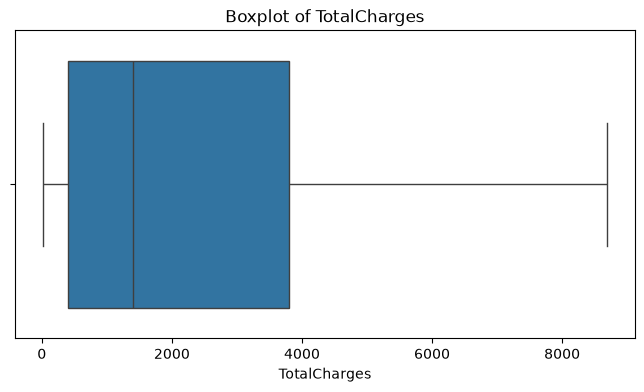

In [31]:
for column in numeric_features:

    plt.figure(figsize=(8, 4))

    sns.boxplot(
        x=df[column]
    )

    plt.title(f"Boxplot of {column}")

    plt.show()

In [32]:
outlier_summary = []

for column in numeric_features:

    Q1 = df[column].quantile(0.25)
    Q3 = df[column].quantile(0.75)

    IQR = Q3 - Q1

    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    outliers = df[
        (df[column] < lower_bound) |
        (df[column] > upper_bound)
    ]

    outlier_count = len(outliers)

    outlier_percentage = (
        outlier_count / len(df)
    ) * 100

    outlier_summary.append({
        "Feature": column,
        "Q1": Q1,
        "Q3": Q3,
        "IQR": IQR,
        "Lower Bound": lower_bound,
        "Upper Bound": upper_bound,
        "Outlier Count": outlier_count,
        "Outlier %": outlier_percentage
    })


outlier_df = pd.DataFrame(outlier_summary)


In [33]:
contract_churn_rate = pd.crosstab(
    df["Contract"],
    df["Churn"],
    normalize="index"
) * 100

print(contract_churn_rate)

Churn                  No        Yes
Contract                            
Month-to-month  57.290323  42.709677
One year        88.730482  11.269518
Two year        97.168142   2.831858


In [34]:
internet_churn_rate = pd.crosstab(
    df["InternetService"],
    df["Churn"],
    normalize="index"
) * 100

print(internet_churn_rate)

Churn                   No        Yes
InternetService                      
DSL              81.040892  18.959108
Fiber optic      58.107235  41.892765
No               92.595020   7.404980


In [35]:
payment_churn_rate = pd.crosstab(
    df["PaymentMethod"],
    df["Churn"],
    normalize="index"
) * 100

print(payment_churn_rate)

Churn                             No        Yes
PaymentMethod                                  
Bank transfer (automatic)  83.290155  16.709845
Credit card (automatic)    84.756899  15.243101
Electronic check           54.714588  45.285412
Mailed check               80.893300  19.106700


In [36]:
techsupport_churn_rate = pd.crosstab(
    df["TechSupport"],
    df["Churn"],
    normalize="index"
) * 100

print(techsupport_churn_rate)

Churn                       No        Yes
TechSupport                              
No                   58.364526  41.635474
No internet service  92.595020   7.404980
Yes                  84.833659  15.166341


In [37]:
techsupport_churn_rate = pd.crosstab(
    df["TechSupport"],
    df["Churn"],
    normalize="index"
) * 100

print(techsupport_churn_rate)

Churn                       No        Yes
TechSupport                              
No                   58.364526  41.635474
No internet service  92.595020   7.404980
Yes                  84.833659  15.166341


In [38]:
security_churn_rate = pd.crosstab(
    df["OnlineSecurity"],
    df["Churn"],
    normalize="index"
) * 100

print(security_churn_rate)

Churn                       No        Yes
OnlineSecurity                           
No                   58.233276  41.766724
No internet service  92.595020   7.404980
Yes                  85.388806  14.611194


In [39]:

for column in categorical_features:

    print("\n" + "=" * 50)
    print(column)
    print("=" * 50)

    churn_rate = pd.crosstab(
        df[column],
        df["Churn"],
        normalize="index"
    ) * 100

    print(churn_rate.round(2))


gender
Churn      No    Yes
gender              
Female  73.08  26.92
Male    73.84  26.16

Contract
Churn              No    Yes
Contract                    
Month-to-month  57.29  42.71
One year        88.73  11.27
Two year        97.17   2.83

InternetService
Churn               No    Yes
InternetService              
DSL              81.04  18.96
Fiber optic      58.11  41.89
No               92.60   7.40

PaymentMethod
Churn                         No    Yes
PaymentMethod                          
Bank transfer (automatic)  83.29  16.71
Credit card (automatic)    84.76  15.24
Electronic check           54.71  45.29
Mailed check               80.89  19.11

Partner
Churn       No    Yes
Partner              
No       67.04  32.96
Yes      80.34  19.66

Dependents
Churn          No    Yes
Dependents              
No          68.72  31.28
Yes         84.55  15.45

PhoneService
Churn            No    Yes
PhoneService              
No            75.07  24.93
Yes           73.29  26.71


In [40]:
df["TotalCharges"] = pd.to_numeric(
    df["TotalCharges"],
    errors="coerce"
)

df["Churn_Encoded"] = df["Churn"].map({
    "No": 0,
    "Yes": 1
})

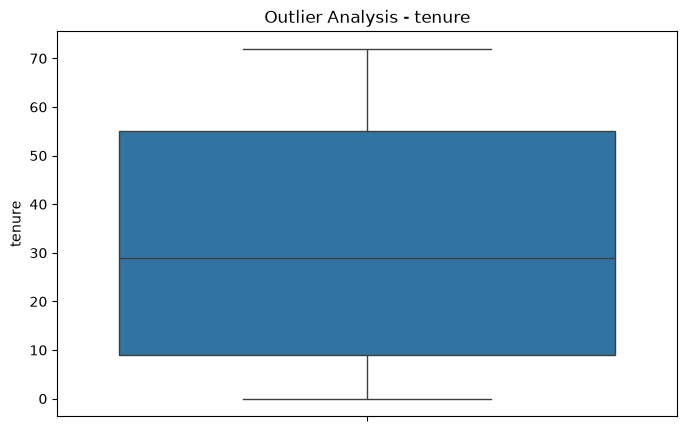

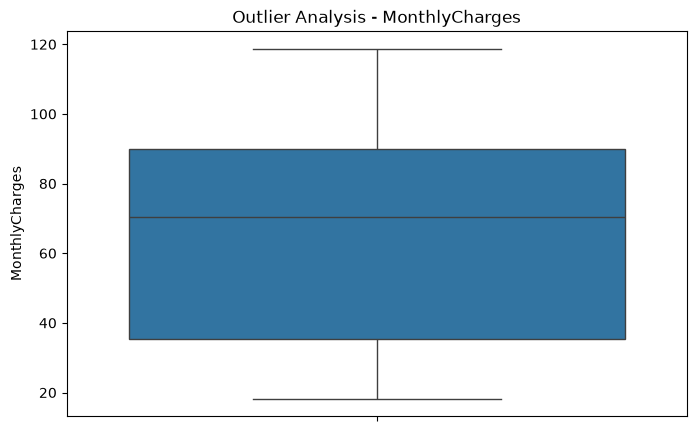

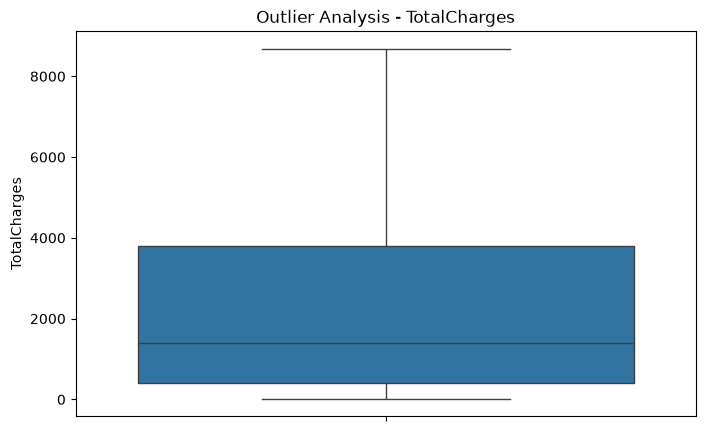

In [41]:
numeric_features = [
    "tenure",
    "MonthlyCharges",
    "TotalCharges"
]

for column in numeric_features:

    plt.figure(figsize=(8, 5))

    sns.boxplot(
        y=df[column]
    )

    plt.title(f"Outlier Analysis - {column}")
    plt.ylabel(column)

    plt.show()

In [42]:
for column in numeric_features:

    Q1 = df[column].quantile(0.25)
    Q3 = df[column].quantile(0.75)

    IQR = Q3 - Q1

    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    outliers = df[
        (df[column] < lower_bound) |
        (df[column] > upper_bound)
    ]

    print("\n", "=" * 50)
    print(column)
    print("=" * 50)

    print("Q1:", Q1)
    print("Q3:", Q3)
    print("IQR:", IQR)

    print("Lower Bound:", lower_bound)
    print("Upper Bound:", upper_bound)

    print("Outlier Count:", len(outliers))

    print(
        "Outlier Percentage:",
        round((len(outliers) / len(df)) * 100, 2),
        "%"
    )


tenure
Q1: 9.0
Q3: 55.0
IQR: 46.0
Lower Bound: -60.0
Upper Bound: 124.0
Outlier Count: 0
Outlier Percentage: 0.0 %

MonthlyCharges
Q1: 35.5
Q3: 89.85
IQR: 54.349999999999994
Lower Bound: -46.02499999999999
Upper Bound: 171.375
Outlier Count: 0
Outlier Percentage: 0.0 %

TotalCharges
Q1: 401.45
Q3: 3794.7375
IQR: 3393.2875000000004
Lower Bound: -4688.481250000001
Upper Bound: 8884.66875
Outlier Count: 0
Outlier Percentage: 0.0 %


In [43]:
skewness = df[numeric_features].skew()

print("Skewness:")
print(skewness)

Skewness:
tenure            0.239540
MonthlyCharges   -0.220524
TotalCharges      0.961642
dtype: float64


          tenure                   MonthlyCharges                     \
            mean median        std           mean  median        std   
Churn                                                                  
No     37.569965   38.0  24.113777      61.265124  64.425  31.092648   
Yes    17.979133   10.0  19.531123      74.441332  79.650  24.666053   

      TotalCharges                        
              mean   median          std  
Churn                                     
No     2555.344141  1683.60  2329.456984  
Yes    1531.796094   703.55  1890.822994  
Mean values by Churn:
          tenure  MonthlyCharges  TotalCharges
Churn                                         
No     37.569965       61.265124   2555.344141
Yes    17.979133       74.441332   1531.796094

Median values by Churn:
       tenure  MonthlyCharges  TotalCharges
Churn                                      
No       38.0          64.425       1683.60
Yes      10.0          79.650        703.55


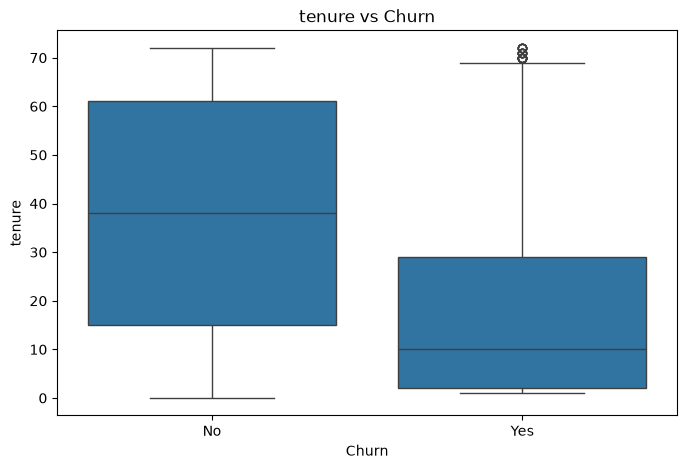

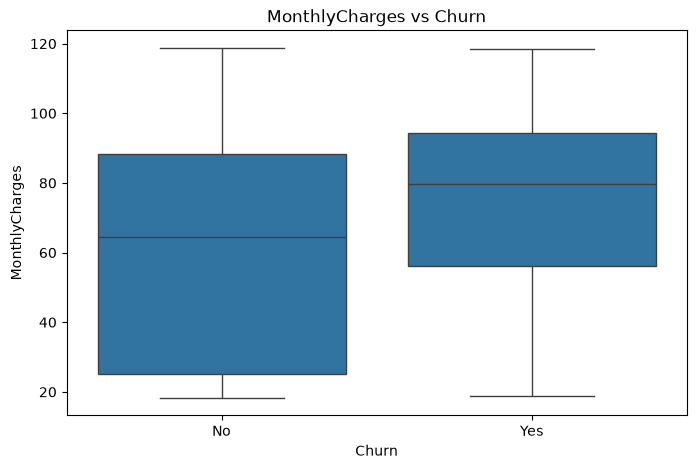

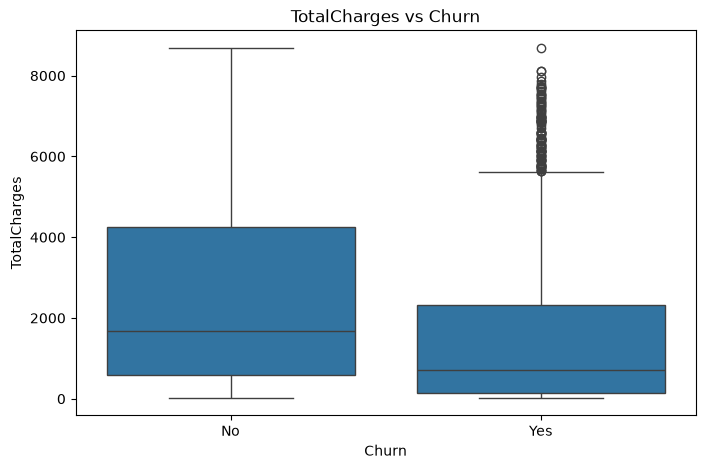

In [44]:
group_statistics = df.groupby("Churn")[numeric_features].agg(
    ["mean", "median", "std"]
)

print(group_statistics)

mean_by_churn = df.groupby("Churn")[numeric_features].mean()

print("Mean values by Churn:")
print(mean_by_churn)

median_by_churn = df.groupby("Churn")[numeric_features].median()

print("\nMedian values by Churn:")
print(median_by_churn)

for column in numeric_features:

    plt.figure(figsize=(8, 5))

    sns.boxplot(
        data=df,
        x="Churn",
        y=column
    )

    plt.title(f"{column} vs Churn")

    plt.show()